In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

In [4]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam':1})
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
  df['Text'],
  df['label_enc'],
  test_size = 0.2,
  random_state = 42
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


In [19]:
avg_words_len = round(sum([len(i.split())
                  for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


In [21]:
def compile_and_fit(model, epochs=5):
  model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
  )
  history = model.fit(
    X_train_np,
    y_train_np,
    epochs = epochs,
    validation_data = (X_test_np, y_test_np)
  )
  return history

def get_metrics(model, X, y):
  y_preds = np.round(model.predict(X))
  return {
    'accuracy': accuracy_score(y,y_preds),
    'precision': precision_score(y, y_preds),
    'recall': recall_score(y,y_preds),
    'f1-score': f1_score(y,y_preds)
  }

In [25]:
from tensorflow.keras.layers import TextVectorization 
text_vec = TextVectorization(
  max_tokens = total_words_length,
  standardize = 'lower_and_strip_punctuation',
  output_mode = 'int',
  output_sequence_length = avg_words_len
)

text_vec.adapt(X_train_np)

In [31]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name='Dense_Model')
history_1 = compile_and_fit(model_1)


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9129 - loss: 0.2748 - val_accuracy: 0.9605 - val_loss: 0.1397
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9800 - loss: 0.0825 - val_accuracy: 0.9776 - val_loss: 0.0829
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9899 - loss: 0.0393 - val_accuracy: 0.9767 - val_loss: 0.0639
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9948 - loss: 0.0236 - val_accuracy: 0.9794 - val_loss: 0.0630
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9971 - loss: 0.0147 - val_accuracy: 0.9794 - val_loss: 0.0646


In [36]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name='BiLSTM_Model')
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9495 - loss: 0.1603 - val_accuracy: 0.9731 - val_loss: 0.0902
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9901 - loss: 0.0356 - val_accuracy: 0.9758 - val_loss: 0.0702
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9980 - loss: 0.0095 - val_accuracy: 0.9713 - val_loss: 0.0929
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 0.9758 - val_loss: 0.1355
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9987 - loss: 0.0055 - val_accuracy: 0.9749 - val_loss: 0.0890


In [38]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_3 = keras.Model(input_layer, output_layer, name='USE_Model')

history_3 = compile_and_fit(model_3)


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9248 - loss: 0.2591 - val_accuracy: 0.9749 - val_loss: 0.1024
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9796 - loss: 0.0764 - val_accuracy: 0.9803 - val_loss: 0.0668
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9850 - loss: 0.0540 - val_accuracy: 0.9821 - val_loss: 0.0570
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9868 - loss: 0.0447 - val_accuracy: 0.9830 - val_loss: 0.0533
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9890 - loss: 0.0384 - val_accuracy: 0.9839 - val_loss: 0.0523


In [39]:
results = {
  'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
  'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
  'Transfer Learning': get_metrics(model_1, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print('Performance Table:')
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step
Performance Table:
                   accuracy  precision    recall  f1-score
Dense Embedding    0.979372   0.970149  0.872483  0.918728
Bi-LSTM            0.974888   0.941606  0.865772  0.902098
Transfer Learning  0.979372   0.970149  0.872483  0.918728


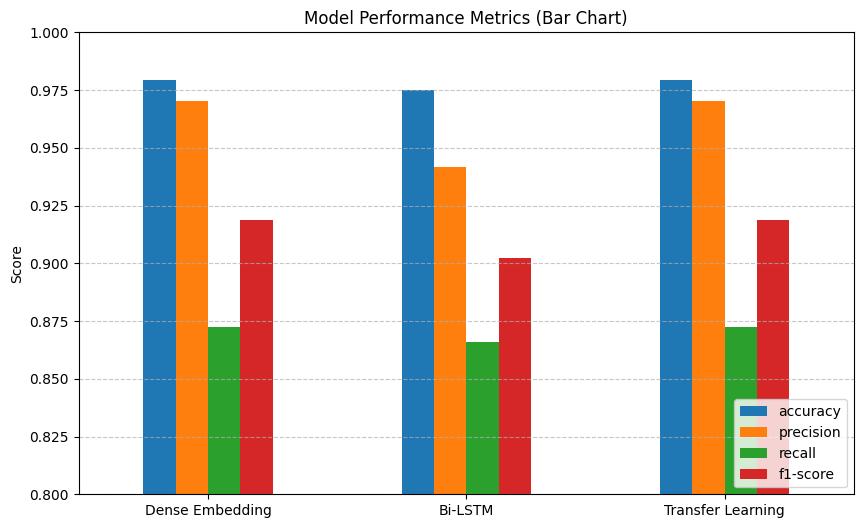

In [40]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

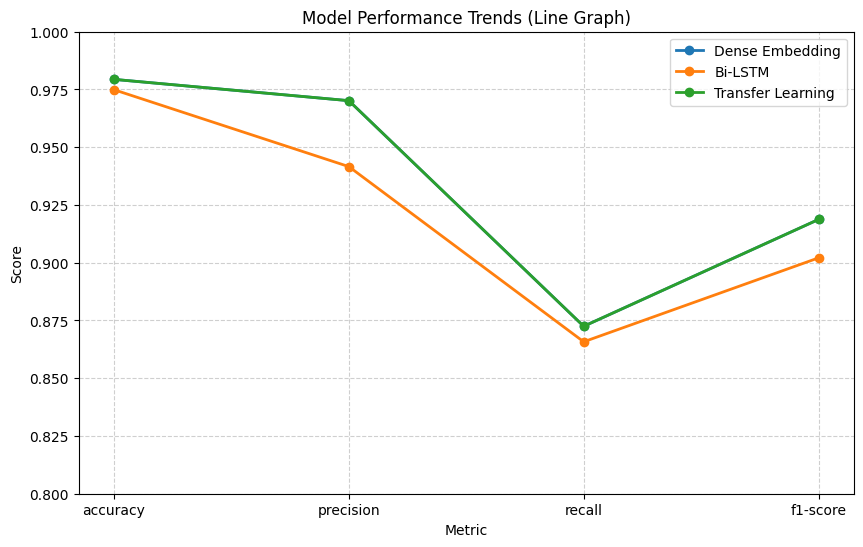

In [42]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()